In [ ]:
import pandas as pd

df = pd.read_csv("/content/Social_Network_Ads.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import joblib

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [ ]:
print(df.shape)

(400, 5)


In [ ]:
print(df.columns)

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [ ]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])

In [ ]:
correlation = df.corr(numeric_only=True)
print(correlation)

                  User ID    Gender       Age  EstimatedSalary  Purchased
User ID          1.000000 -0.025249 -0.000721         0.071097   0.007120
Gender          -0.025249  1.000000 -0.073741        -0.060435  -0.042469
Age             -0.000721 -0.073741  1.000000         0.155238   0.622454
EstimatedSalary  0.071097 -0.060435  0.155238         1.000000   0.362083
Purchased        0.007120 -0.042469  0.622454         0.362083   1.000000


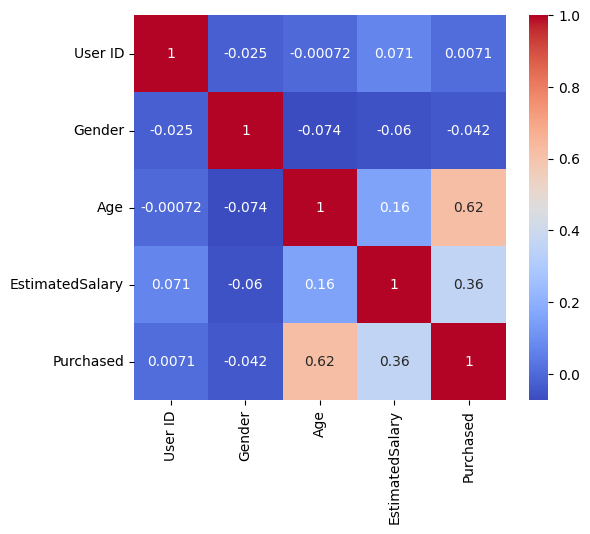

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

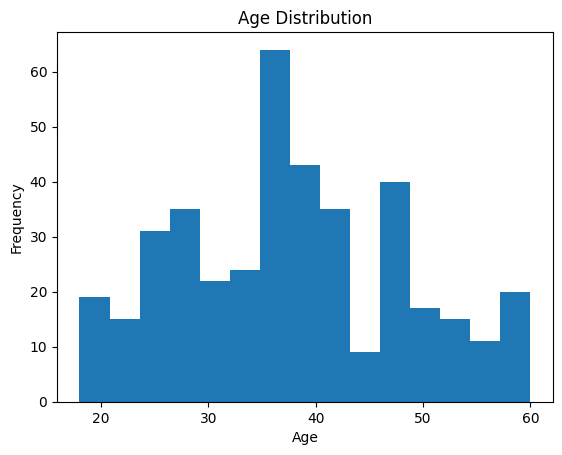

In [ ]:
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

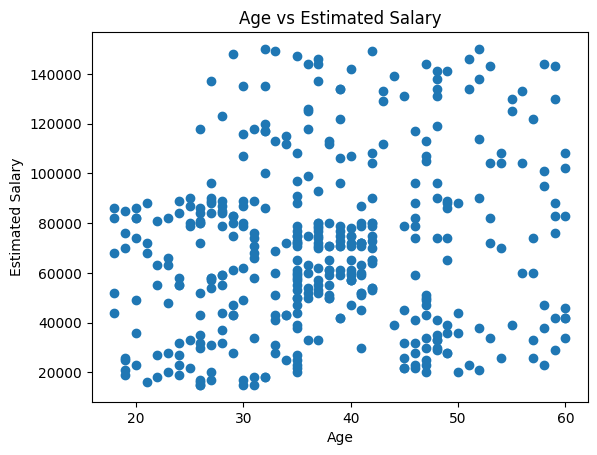

In [ ]:
plt.scatter(df["Age"], df["EstimatedSalary"])
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Age vs Estimated Salary")
plt.show()

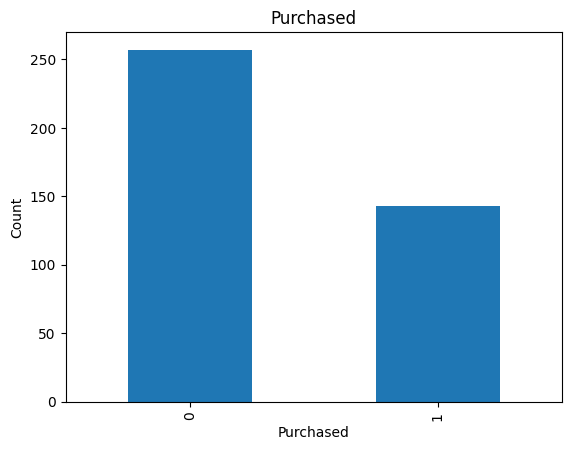

In [ ]:
df["Purchased"].value_counts().plot(kind="bar")
plt.title("Purchased")
plt.xlabel("Purchased")
plt.ylabel("Count")
plt.show()

In [ ]:
x = df.drop(["Purchased", "User ID"], axis=1)
y = df["Purchased"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)

LogisticRegression()

In [ ]:
lr_pred = lr_model.predict(x_test)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression
Accuracy : 0.8875
Precision: 0.9130434782608695
Recall   : 0.75
F1 Score : 0.8235294117647058
[[50  2]
 [ 7 21]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
knn_pred = knn_model.predict(x_test)

print("KNN")
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))

print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN
Accuracy : 0.925
Precision: 0.8666666666666667
Recall   : 0.9285714285714286
F1 Score : 0.896551724137931
[[48  4]
 [ 2 26]]
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_pred = dt_model.predict(x_test)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree
Accuracy : 0.85
Precision: 0.8076923076923077
Recall   : 0.75
F1 Score : 0.7777777777777778
[[47  5]
 [ 7 21]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.89        52
           1       0.81      0.75      0.78        28

    accuracy                           0.85        80
   macro avg       0.84      0.83      0.83        80
weighted avg       0.85      0.85      0.85        80



In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, dt_pred)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.8875   0.913043  0.750000  0.823529
1                  KNN    0.9250   0.866667  0.928571  0.896552
2        Decision Tree    0.8500   0.807692  0.750000  0.777778


In [ ]:
lr_acc = accuracy_score(y_test, lr_pred)
knn_acc = accuracy_score(y_test, knn_pred)
dt_acc = accuracy_score(y_test, dt_pred)

if lr_acc >= knn_acc and lr_acc >= dt_acc:
    best_model = lr_model
    print("Best Model: Logistic Regression")
elif knn_acc >= lr_acc and knn_acc >= dt_acc:
    best_model = knn_model
    print("Best Model: KNN")
else:
    best_model = dt_model
    print("Best Model: Decision Tree")

Best Model: KNN


In [ ]:
joblib.dump(best_model, "best_customer_purchase_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [ ]:
loaded_model = joblib.load("best_customer_purchase_model.pkl")
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
def predict_customer(gender, age, salary):
    gender = encoder.transform([gender])[0]

    new_data = pd.DataFrame([[gender, age, salary]],
                            columns=["Gender", "Age", "EstimatedSalary"])

    new_data = scaler.transform(new_data)

    prediction = loaded_model.predict(new_data)

    if prediction[0] == 1:
        print("Customer will purchase the product.")
    else:
        print("Customer will not purchase the product.")

In [ ]:
predict_customer("Male", 35, 60000)

Customer will not purchase the product.


In [ ]:
predict_customer("Female", 28, 35000)

Customer will not purchase the product.


In [ ]:
predict_customer("Male", 45, 90000)

Customer will purchase the product.
